# 🛒 E-Commerce Order Fulfillment Efficiency
## Task 3: Deep-Dive Analysis & Interactive Dashboarding

---

| Detail | Info |
|---|---|
| **Dataset** | Olist Brazilian E-Commerce Public Dataset |
| **Analyst** | Your Name |
| **Tool** | Python · Pandas · Seaborn · Plotly · Tableau Public |
| **Date** | March 2026 |

---

### 🎯 Objective
Perform a deep-dive segmentation analysis on seller fulfillment performance.
Classify sellers into performance tiers and identify where operational
intervention will have the highest business impact.

---

### 🔍 Deep-Dive Focus
**Seller Performance Segmentation**
Segment all sellers into four performance tiers based on delivery time
and late delivery rate. Identify Tier 4 critical sellers and quantify
their impact on overall fulfillment quality.

---

### 📦 Building On
All findings from Task 2 EDA — particularly the central finding that
last-mile delivery has r = 0.928 correlation with total delivery time.

In [ ]:
# ============================================================
# CELL 2 | IMPORTS & CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ---- Visual Theme ----
COLORS = {
    'primary'   : '#4361EE',
    'secondary' : '#F72585',
    'accent'    : '#4CC9F0',
    'warning'   : '#F4A261',
    'success'   : '#2DC653',
    'neutral'   : '#6C757D'
}

TIER_COLORS = {
    'Tier 1 - Excellent' : '#2DC653',
    'Tier 2 - Average'   : '#4361EE',
    'Tier 3 - Poor'      : '#F4A261',
    'Tier 4 - Critical'  : '#F72585'
}

plt.rcParams['figure.figsize']    = (13, 5)
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='darkgrid', palette=list(COLORS.values()))

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [ ]:
# ============================================================
# CELL 3 | DATA LOADING
# ============================================================

# --- Load Cleaned Dataset from Task 1 ---
df = pd.read_excel('Cleaned Orders Dataset.xlsx', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

# --- Load Supporting Datasets ---
items_df       = pd.read_csv('olist_order_items_dataset.csv')
products_df    = pd.read_csv('olist_products_dataset.csv')
sellers_df     = pd.read_csv('olist_sellers_dataset.csv')
customers_df   = pd.read_csv('olist_customers_dataset.csv')
translation_df = pd.read_csv('product_category_name_translation.csv')

# --- Recreate df_clean from Task 2 ---
# Standardise features
df['delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.total_seconds() / 86400

df['shipping_days'] = (
    df['order_delivered_carrier_date'] -
    df['order_purchase_timestamp']
).dt.total_seconds() / 86400

df['approval_delay'] = (
    df['order_approved_at'] -
    df['order_purchase_timestamp']
).dt.total_seconds() / 86400

df['delivery_status'] = np.where(
    df['order_delivered_customer_date'] <=
    df['order_estimated_delivery_date'],
    'On Time', 'Late'
)

df['delivery_deviation'] = (
    df['order_delivered_customer_date'] -
    df['order_estimated_delivery_date']
).dt.total_seconds() / 86400

# Remove anomalies
df_clean = df[df['shipping_days'] >= 0].copy()

# Translate product categories
products_df = products_df.merge(
    translation_df,
    on='product_category_name',
    how='left'
)

print("=" * 50)
print("       DATASET LOADING SUMMARY")
print("=" * 50)
print(f"  ✅ Cleaned orders  : {len(df_clean):,}")
print(f"  ✅ Order items     : {len(items_df):,}")
print(f"  ✅ Products        : {len(products_df):,}")
print(f"  ✅ Sellers         : {len(sellers_df):,}")
print(f"  ✅ Customers       : {len(customers_df):,}")
print("=" * 50)
print(f"\n📅 Date range: "
      f"{df_clean['order_purchase_timestamp'].min().date()} → "
      f"{df_clean['order_purchase_timestamp'].max().date()}")

       DATASET LOADING SUMMARY
  ✅ Cleaned orders  : 96,315
  ✅ Order items     : 112,650
  ✅ Products        : 32,951
  ✅ Sellers         : 3,095
  ✅ Customers       : 99,441

📅 Date range: 2016-09-15 → 2018-08-29


---
## 📊 Phase 1: Core KPI Definitions

| KPI | Formula | Business Rationale |
|---|---|---|
| **On-Time Delivery Rate** | % orders ≤ estimated date | Core customer promise metric |
| **Average Fulfillment Time** | Mean delivery_days | Overall efficiency benchmark |
| **Carrier Handoff Speed** | Mean shipping_days | Seller dispatch performance |
| **Estimation Accuracy** | Mean delivery_deviation | Buffer management health |
| **Seller Late Rate** | % late orders per seller | Seller accountability metric |

These 5 KPIs form the measurement framework for the
segmentation analysis in Phase 2.

In [ ]:
# ============================================================
# CELL 5 | BUILD SELLER PERFORMANCE PROFILE
# ============================================================
# Aggregate all order-level data up to seller level
# This gives us one row per seller with all KPIs calculated
# ============================================================

# Step 1 — Join orders with order items to get seller_id
seller_orders = df_clean.merge(
    items_df[['order_id', 'seller_id', 'price', 'freight_value']],
    on='order_id',
    how='inner'
)

# Step 2 — Join with sellers to get seller state
seller_orders = seller_orders.merge(
    sellers_df[['seller_id', 'seller_state', 'seller_city']],
    on='seller_id',
    how='left'
)

print(f"✅ Seller orders joined : {len(seller_orders):,} rows")
print(f"   Unique sellers       : {seller_orders['seller_id'].nunique():,}")
print(f"   Unique orders        : {seller_orders['order_id'].nunique():,}")

# Step 3 — Aggregate to seller level
seller_profile = seller_orders.groupby('seller_id').agg(
    total_orders      = ('order_id',        'nunique'),
    seller_state      = ('seller_state',    'first'),
    seller_city       = ('seller_city',     'first'),
    avg_delivery_days = ('delivery_days',   'mean'),
    avg_shipping_days = ('shipping_days',   'mean'),
    avg_approval_delay= ('approval_delay',  'mean'),
    total_revenue     = ('price',           'sum'),
    avg_freight       = ('freight_value',   'mean'),
    late_orders       = ('delivery_status', lambda x: (x == 'Late').sum()),
    on_time_orders    = ('delivery_status', lambda x: (x == 'On Time').sum()),
    avg_deviation     = ('delivery_deviation', 'mean')
).reset_index()

# Step 4 — Calculate late rate
seller_profile['late_rate_pct'] = (
    seller_profile['late_orders'] /
    seller_profile['total_orders'] * 100
).round(2)

# Step 5 — Round numeric columns
seller_profile['avg_delivery_days']  = seller_profile['avg_delivery_days'].round(2)
seller_profile['avg_shipping_days']  = seller_profile['avg_shipping_days'].round(2)
seller_profile['avg_approval_delay'] = seller_profile['avg_approval_delay'].round(2)
seller_profile['total_revenue']      = seller_profile['total_revenue'].round(2)
seller_profile['avg_deviation']      = seller_profile['avg_deviation'].round(2)

# Filter to sellers with minimum 10 orders for statistical reliability
seller_profile = seller_profile[
    seller_profile['total_orders'] >= 10
].copy()

print(f"\n=== SELLER PROFILE SUMMARY ===\n")
print(f"  Sellers with 10+ orders : {len(seller_profile):,}")
print(f"  Total orders covered    : {seller_profile['total_orders'].sum():,}")
print(f"\n  Avg delivery days : {seller_profile['avg_delivery_days'].mean():.2f}")
print(f"  Avg shipping days : {seller_profile['avg_shipping_days'].mean():.2f}")
print(f"  Avg late rate     : {seller_profile['late_rate_pct'].mean():.2f}%")
print(f"  Total revenue     : R$ {seller_profile['total_revenue'].sum():,.2f}")

✅ Seller orders joined : 110,014 rows
   Unique sellers       : 2,967
   Unique orders        : 96,315

=== SELLER PROFILE SUMMARY ===

  Sellers with 10+ orders : 1,236
  Total orders covered    : 91,698

  Avg delivery days : 12.13
  Avg shipping days : 3.24
  Avg late rate     : 8.77%
  Total revenue     : R$ 11,987,948.42


In [ ]:
# ============================================================
# CELL 6 | SELLER PERFORMANCE TIER ASSIGNMENT
# ============================================================
# Segmentation logic based on two dimensions:
#   1. avg_delivery_days vs national median
#   2. late_rate_pct vs national benchmark
#
# Tier 1 - Excellent : Fast delivery AND low late rate
# Tier 2 - Average   : One dimension slightly above benchmark
# Tier 3 - Poor      : One dimension clearly above benchmark
# Tier 4 - Critical  : Both dimensions above benchmark
# ============================================================

# Define thresholds based on national benchmarks from Task 2
delivery_median   = df_clean['delivery_days'].median()
delivery_75th     = df_clean['delivery_days'].quantile(0.75)
national_late_avg = (df_clean['delivery_status'] == 'Late').mean() * 100

print(f"=== SEGMENTATION THRESHOLDS ===\n")
print(f"  Delivery median    : {delivery_median:.2f} days")
print(f"  Delivery 75th pct  : {delivery_75th:.2f} days")
print(f"  National late rate : {national_late_avg:.2f}%")

# Tier assignment function
def assign_tier(row):
    fast     = row['avg_delivery_days'] <= delivery_median
    slow     = row['avg_delivery_days'] >  delivery_75th
    low_late = row['late_rate_pct']     <= national_late_avg
    high_late= row['late_rate_pct']     >  national_late_avg * 2

    if fast and low_late:
        return 'Tier 1 - Excellent'
    elif slow and high_late:
        return 'Tier 4 - Critical'
    elif slow or high_late:
        return 'Tier 3 - Poor'
    else:
        return 'Tier 2 - Average'

seller_profile['performance_tier'] = seller_profile.apply(
    assign_tier, axis=1
)

# ============================================================
# TIER DISTRIBUTION SUMMARY
# ============================================================

tier_summary = seller_profile.groupby('performance_tier').agg(
    seller_count      = ('seller_id',        'count'),
    total_orders      = ('total_orders',     'sum'),
    avg_delivery_days = ('avg_delivery_days','mean'),
    avg_late_rate     = ('late_rate_pct',    'mean'),
    total_revenue     = ('total_revenue',    'sum')
).round(2).reset_index()

tier_summary['pct_of_sellers'] = (
    tier_summary['seller_count'] /
    tier_summary['seller_count'].sum() * 100
).round(1)

tier_summary['pct_of_orders'] = (
    tier_summary['total_orders'] /
    tier_summary['total_orders'].sum() * 100
).round(1)

print(f"\n=== TIER DISTRIBUTION ===\n")
print(tier_summary[[
    'performance_tier', 'seller_count', 'pct_of_sellers',
    'total_orders', 'pct_of_orders',
    'avg_delivery_days', 'avg_late_rate'
]].to_string(index=False))

=== SEGMENTATION THRESHOLDS ===

  Delivery median    : 10.22 days
  Delivery 75th pct  : 15.73 days
  National late rate : 8.12%

=== TIER DISTRIBUTION ===

  performance_tier  seller_count  pct_of_sellers  total_orders  pct_of_orders  avg_delivery_days  avg_late_rate
Tier 1 - Excellent           296            23.9         15135           16.5               8.46           2.54
  Tier 2 - Average           690            55.8         64937           70.8              12.15           7.34
     Tier 3 - Poor           171            13.8          8370            9.1              14.79          17.13
 Tier 4 - Critical            79             6.4          3256            3.6              19.96          26.52


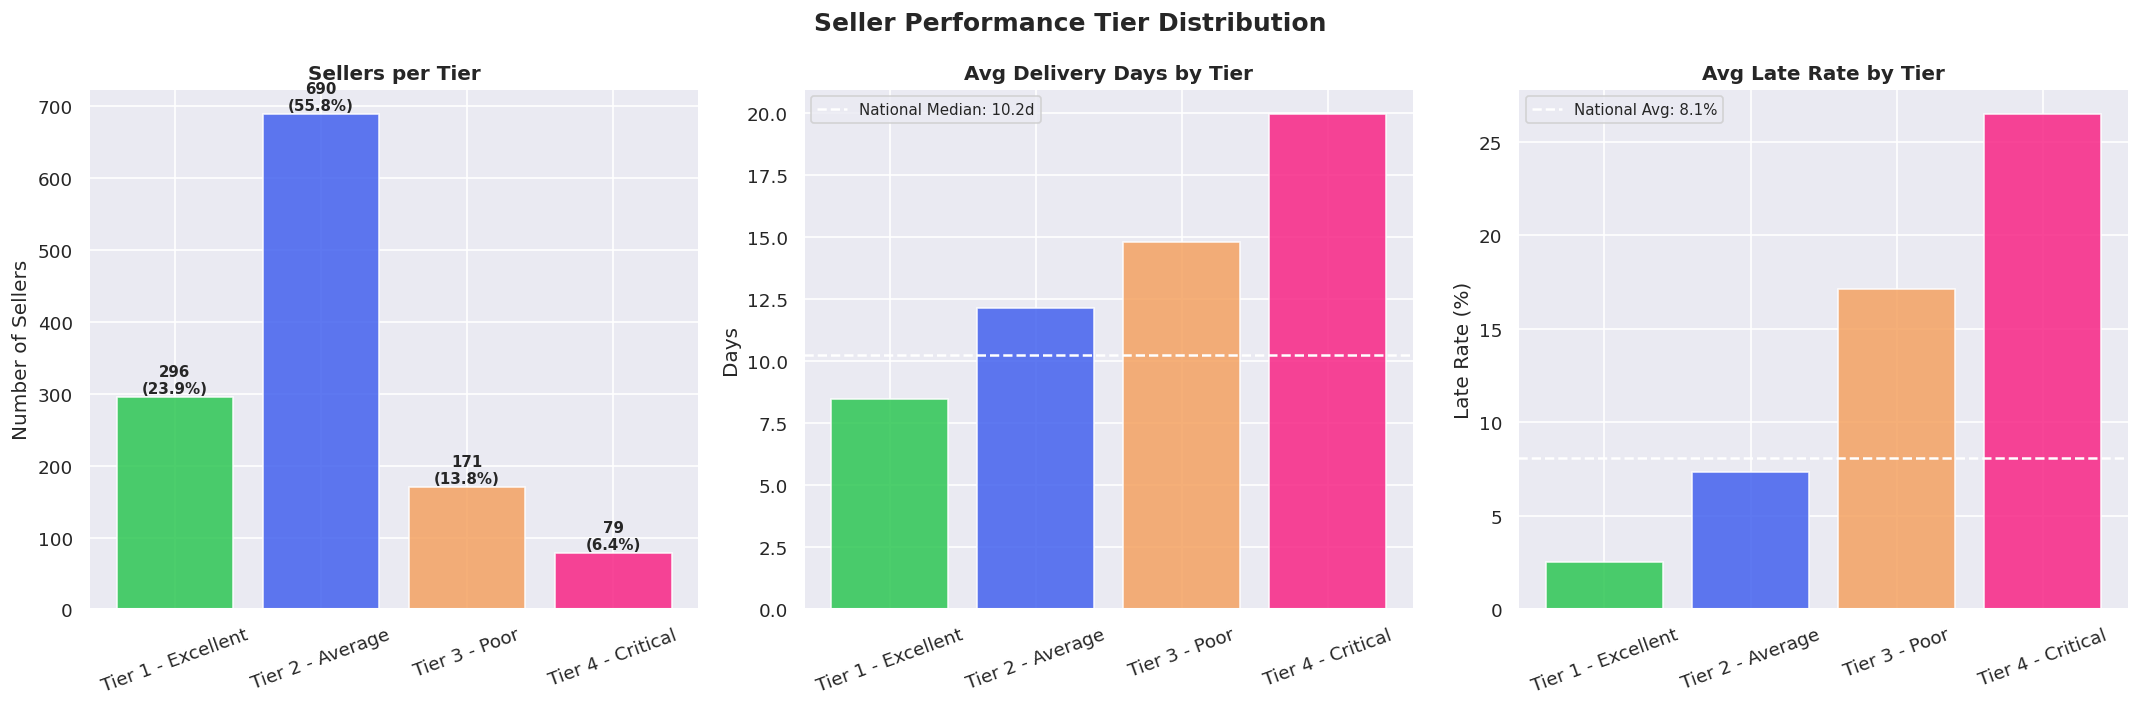

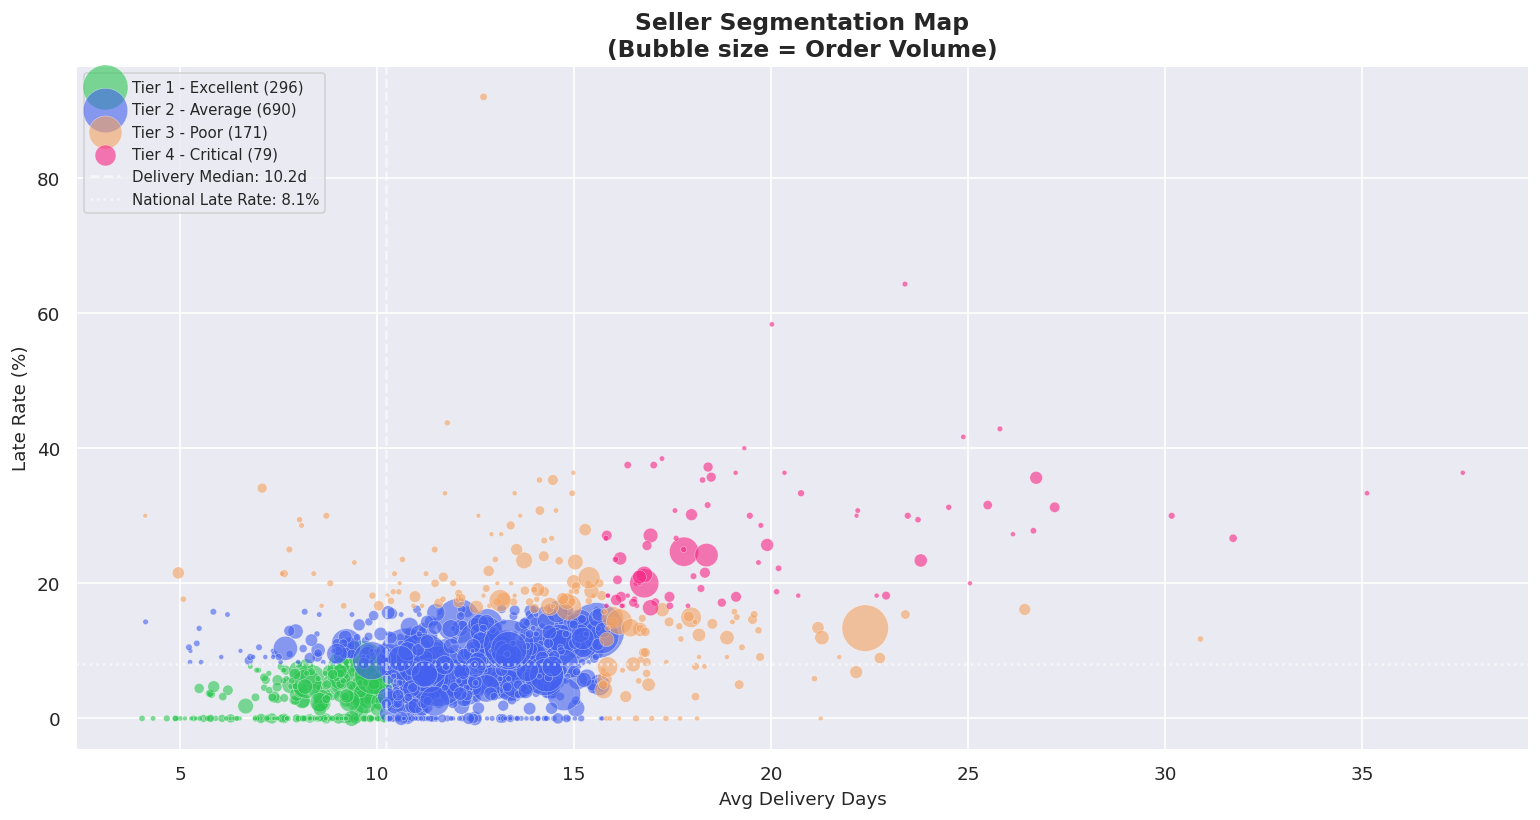

✅ Tier visualisations complete


In [ ]:
# ============================================================
# CELL 7 | TIER VISUALISATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Seller Performance Tier Distribution',
             fontsize=15, fontweight='bold')

tier_order  = ['Tier 1 - Excellent', 'Tier 2 - Average',
               'Tier 3 - Poor',      'Tier 4 - Critical']
tier_colors = [TIER_COLORS[t] for t in tier_order]

# Sort tier summary
tier_summary['performance_tier'] = pd.Categorical(
    tier_summary['performance_tier'],
    categories=tier_order, ordered=True
)
tier_summary = tier_summary.sort_values('performance_tier')

# --- Chart A: Seller Count by Tier ---
bars = axes[0].bar(
    tier_summary['performance_tier'],
    tier_summary['seller_count'],
    color=tier_colors, alpha=0.85
)
axes[0].set_title('Sellers per Tier', fontweight='bold')
axes[0].set_ylabel('Number of Sellers')
axes[0].tick_params(axis='x', rotation=20)

for bar, val, pct in zip(
    bars,
    tier_summary['seller_count'],
    tier_summary['pct_of_sellers']
):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'{val}\n({pct}%)',
        ha='center', fontsize=9, fontweight='bold'
    )

# --- Chart B: Avg Delivery Days by Tier ---
axes[1].bar(
    tier_summary['performance_tier'],
    tier_summary['avg_delivery_days'],
    color=tier_colors, alpha=0.85
)
axes[1].axhline(
    delivery_median,
    color='white', linestyle='--', linewidth=1.5,
    label=f'National Median: {delivery_median:.1f}d'
)
axes[1].set_title('Avg Delivery Days by Tier',
                  fontweight='bold')
axes[1].set_ylabel('Days')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=9)

# --- Chart C: Avg Late Rate by Tier ---
axes[2].bar(
    tier_summary['performance_tier'],
    tier_summary['avg_late_rate'],
    color=tier_colors, alpha=0.85
)
axes[2].axhline(
    national_late_avg,
    color='white', linestyle='--', linewidth=1.5,
    label=f'National Avg: {national_late_avg:.1f}%'
)
axes[2].set_title('Avg Late Rate by Tier',
                  fontweight='bold')
axes[2].set_ylabel('Late Rate (%)')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ---- Scatter: All sellers plotted by tier ----
fig2, ax = plt.subplots(figsize=(13, 7))

for tier in tier_order:
    subset = seller_profile[
        seller_profile['performance_tier'] == tier
    ]
    ax.scatter(
        subset['avg_delivery_days'],
        subset['late_rate_pct'],
        c     = TIER_COLORS[tier],
        label = f"{tier} ({len(subset)})",
        alpha = 0.6,
        s     = subset['total_orders'] * 0.8,
        edgecolors='white', linewidth=0.3
    )

ax.axvline(delivery_median, color='white',
           linestyle='--', linewidth=1.5, alpha=0.6,
           label=f'Delivery Median: {delivery_median:.1f}d')
ax.axhline(national_late_avg, color='white',
           linestyle=':', linewidth=1.5, alpha=0.6,
           label=f'National Late Rate: {national_late_avg:.1f}%')

ax.set_title('Seller Segmentation Map\n'
             '(Bubble size = Order Volume)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Delivery Days', fontsize=11)
ax.set_ylabel('Late Rate (%)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

print("✅ Tier visualisations complete")

In [ ]:
# ============================================================
# CELL 8 | TIER 4 DEEP DIVE — CRITICAL SELLERS
# ============================================================
# Who are the 79 critical sellers?
# What is their collective impact on fulfillment quality?
# ============================================================

tier4 = seller_profile[
    seller_profile['performance_tier'] == 'Tier 4 - Critical'
].copy().sort_values('late_rate_pct', ascending=False)

tier1 = seller_profile[
    seller_profile['performance_tier'] == 'Tier 1 - Excellent'
].copy()

print("=" * 65)
print("  TIER 4 — CRITICAL SELLERS DEEP DIVE")
print("=" * 65)

# Impact metrics
total_late_t4  = tier4['late_orders'].sum()
total_orders_t4= tier4['total_orders'].sum()
total_revenue_t4=tier4['total_revenue'].sum()

print(f"\n  Total Tier 4 sellers    : {len(tier4)}")
print(f"  Total orders handled    : {total_orders_t4:,}")
print(f"  Total late orders       : {total_late_t4:,}")
print(f"  Overall late rate       : {total_late_t4/total_orders_t4*100:.1f}%")
print(f"  Total revenue at risk   : R$ {total_revenue_t4:,.2f}")

print(f"\n--- COMPARISON: TIER 4 vs TIER 1 ---\n")
print(f"  {'Metric':<25} {'Tier 1':>12} {'Tier 4':>12} {'Gap':>12}")
print(f"  {'-'*60}")

metrics = [
    ('Avg Delivery Days',
     tier1['avg_delivery_days'].mean(),
     tier4['avg_delivery_days'].mean()),
    ('Avg Shipping Days',
     tier1['avg_shipping_days'].mean(),
     tier4['avg_shipping_days'].mean()),
    ('Avg Late Rate %',
     tier1['late_rate_pct'].mean(),
     tier4['late_rate_pct'].mean()),
    ('Avg Orders per Seller',
     tier1['total_orders'].mean(),
     tier4['total_orders'].mean()),
]

for metric, t1_val, t4_val in metrics:
    gap = t4_val - t1_val
    print(f"  {metric:<25} {t1_val:>12.2f} {t4_val:>12.2f} "
          f"{'+' if gap > 0 else ''}{gap:>11.2f}")

print(f"\n--- TOP 10 WORST TIER 4 SELLERS ---\n")
print(tier4[[
    'seller_id', 'seller_state', 'total_orders',
    'avg_delivery_days', 'avg_shipping_days',
    'late_orders', 'late_rate_pct'
]].head(10).to_string(index=False))

  TIER 4 — CRITICAL SELLERS DEEP DIVE

  Total Tier 4 sellers    : 79
  Total orders handled    : 3,256
  Total late orders       : 797
  Overall late rate       : 24.5%
  Total revenue at risk   : R$ 518,165.65

--- COMPARISON: TIER 4 vs TIER 1 ---

  Metric                          Tier 1       Tier 4          Gap
  ------------------------------------------------------------
  Avg Delivery Days                 8.46        19.96 +      11.50
  Avg Shipping Days                 2.04         6.14 +       4.09
  Avg Late Rate %                   2.54        26.52 +      23.98
  Avg Orders per Seller            51.13        41.22       -9.92

--- TOP 10 WORST TIER 4 SELLERS ---

                       seller_id seller_state  total_orders  avg_delivery_days  avg_shipping_days  late_orders  late_rate_pct
b1b3948701c5c72445495bd161b83a4c           SP            14              23.40              15.66            9          64.29
c37b2059d4f90d4feead554e5246565e           SP            12   

  TOP 15 STATES BY TIER 4 SELLER CONCENTRATION
seller_state  total_sellers  critical_rate  Tier 1 - Excellent  Tier 2 - Average  Tier 3 - Poor  Tier 4 - Critical
          MA            1.0          100.0                 0.0               0.0            0.0                1.0
          MS            2.0           50.0                 0.0               1.0            0.0                1.0
          RN            3.0           33.3                 1.0               1.0            0.0                1.0
          SC           55.0           20.0                 6.0              29.0            9.0               11.0
          BA            8.0           12.5                 2.0               4.0            1.0                1.0
          PR          139.0            6.5                31.0              85.0           14.0                9.0
          DF           16.0            6.2                 3.0              11.0            1.0                1.0
          SP          761.0      

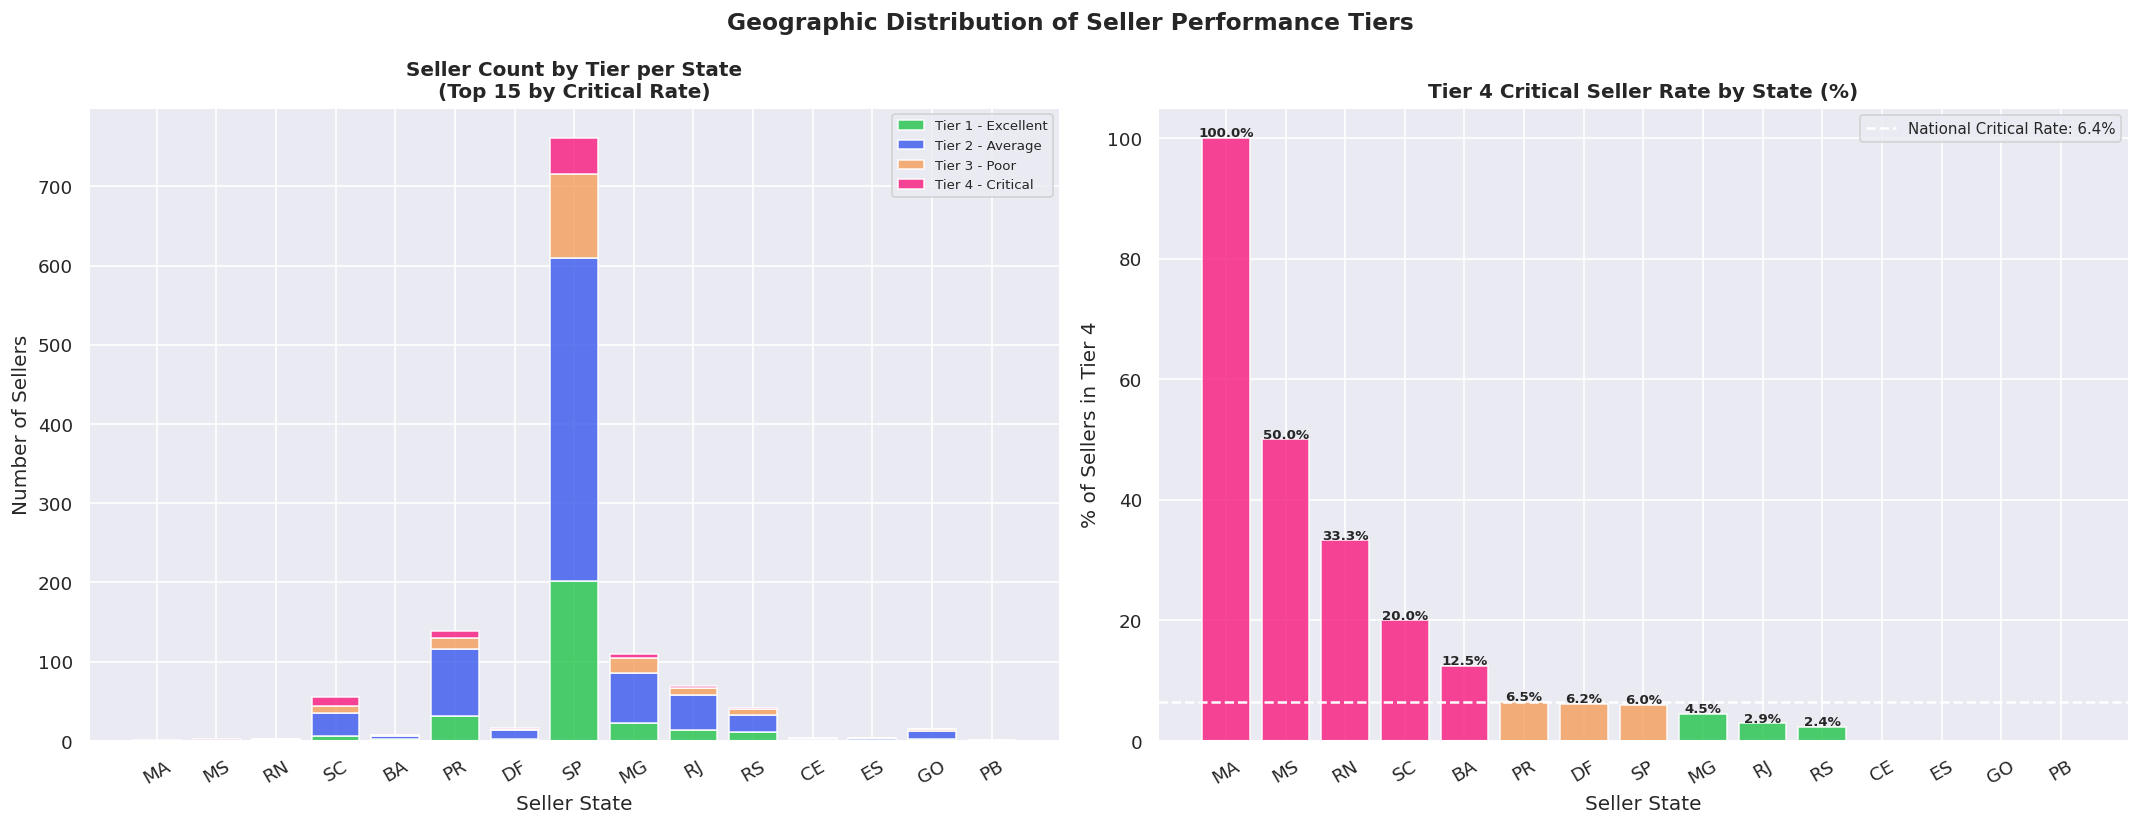

In [ ]:
# ============================================================
# CELL 9 | GEOGRAPHIC DISTRIBUTION OF TIERS
# ============================================================

state_tiers = seller_profile.groupby(
    ['seller_state', 'performance_tier']
).agg(
    seller_count = ('seller_id',    'count'),
    total_orders = ('total_orders', 'sum'),
    avg_late_rate= ('late_rate_pct','mean')
).reset_index()

state_pivot = state_tiers.pivot_table(
    index      = 'seller_state',
    columns    = 'performance_tier',
    values     = 'seller_count',
    fill_value = 0
).reset_index()

state_pivot['total_sellers'] = state_pivot[
    [c for c in state_pivot.columns if 'Tier' in c]
].sum(axis=1)

if 'Tier 4 - Critical' in state_pivot.columns:
    state_pivot['critical_rate'] = (
        state_pivot['Tier 4 - Critical'] /
        state_pivot['total_sellers'] * 100
    ).round(1)
else:
    state_pivot['critical_rate'] = 0

state_pivot = state_pivot.sort_values(
    'critical_rate', ascending=False
).head(15)

tier_cols_present = [
    t for t in tier_order
    if t in state_pivot.columns
]

print("=" * 65)
print("  TOP 15 STATES BY TIER 4 SELLER CONCENTRATION")
print("=" * 65)
print(state_pivot[
    ['seller_state', 'total_sellers', 'critical_rate'] +
    tier_cols_present
].to_string(index=False))

# ---- Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Geographic Distribution of Seller Performance Tiers',
             fontsize=14, fontweight='bold')

# Chart A — Stacked bar by state
bottom = np.zeros(len(state_pivot))

for tier in tier_order:
    if tier in state_pivot.columns:
        axes[0].bar(
            state_pivot['seller_state'],
            state_pivot[tier],
            bottom = bottom,
            color  = TIER_COLORS[tier],
            alpha  = 0.85,
            label  = tier
        )
        bottom += state_pivot[tier].values

axes[0].set_title('Seller Count by Tier per State\n(Top 15 by Critical Rate)',
                  fontweight='bold')
axes[0].set_xlabel('Seller State')
axes[0].set_ylabel('Number of Sellers')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].tick_params(axis='x', rotation=30)

# Chart B — Critical rate by state
colors_crit = [
    COLORS['secondary'] if x > 10
    else COLORS['warning'] if x > 5
    else COLORS['success']
    for x in state_pivot['critical_rate']
]

bars = axes[1].bar(
    state_pivot['seller_state'],
    state_pivot['critical_rate'],
    color = colors_crit,
    alpha = 0.85
)

national_critical_rate = len(tier4) / len(seller_profile) * 100

axes[1].axhline(
    national_critical_rate,
    color='white', linestyle='--', linewidth=1.5,
    label=f'National Critical Rate: {national_critical_rate:.1f}%'
)
axes[1].set_title('Tier 4 Critical Seller Rate by State (%)',
                  fontweight='bold')
axes[1].set_xlabel('Seller State')
axes[1].set_ylabel('% of Sellers in Tier 4')
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=30)

for bar, val in zip(bars, state_pivot['critical_rate']):
    if val > 0:
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{val:.1f}%',
            ha='center', fontsize=8, fontweight='bold'
        )

plt.tight_layout()
plt.show()

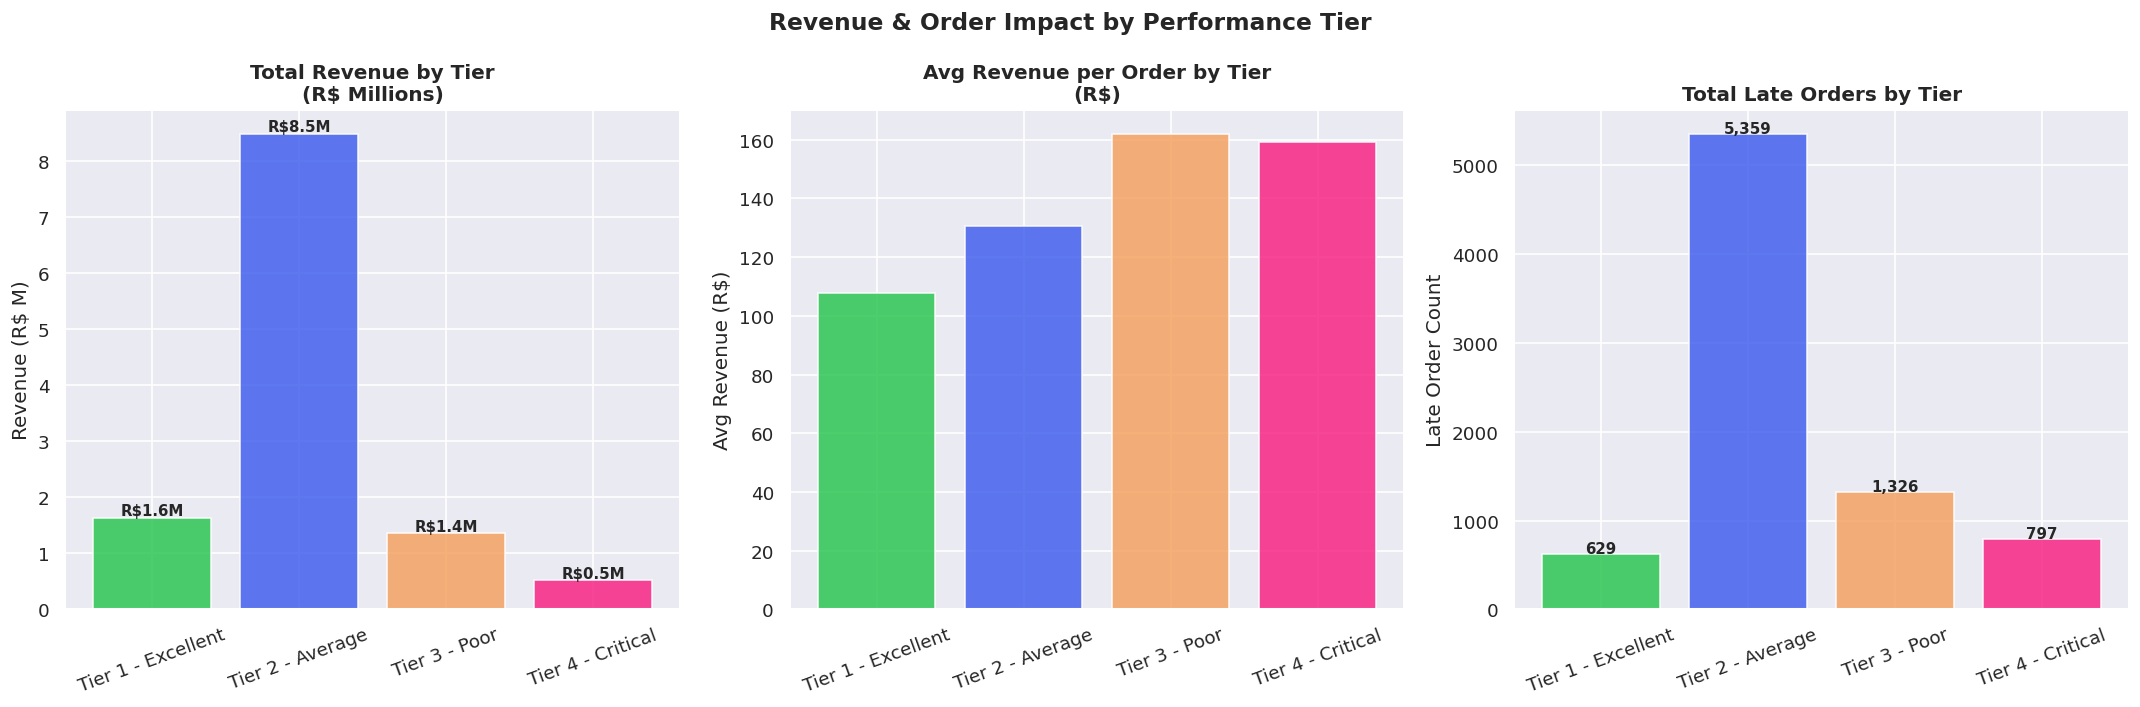

=== REVENUE & IMPACT SUMMARY ===

  Tier 1 - Excellent        Revenue: R$    1,630,343  Late orders:   629
  Tier 2 - Average          Revenue: R$    8,482,838  Late orders: 5,359
  Tier 3 - Poor             Revenue: R$    1,356,602  Late orders: 1,326
  Tier 4 - Critical         Revenue: R$      518,166  Late orders:   797


In [ ]:
# ============================================================
# CELL 10 | REVENUE IMPACT BY TIER
# ============================================================
# What is the revenue exposure from poor performing sellers?
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Revenue & Order Impact by Performance Tier',
             fontsize=14, fontweight='bold')

tier_revenue = seller_profile.groupby('performance_tier').agg(
    total_revenue = ('total_revenue', 'sum'),
    total_orders  = ('total_orders',  'sum'),
    seller_count  = ('seller_id',     'count')
).reset_index()

tier_revenue['performance_tier'] = pd.Categorical(
    tier_revenue['performance_tier'],
    categories=tier_order, ordered=True
)
tier_revenue = tier_revenue.sort_values('performance_tier')

colors_t = [TIER_COLORS[t] for t in tier_revenue['performance_tier']]

# Chart A — Revenue by tier
axes[0].bar(tier_revenue['performance_tier'],
            tier_revenue['total_revenue'] / 1e6,
            color=colors_t, alpha=0.85)
axes[0].set_title('Total Revenue by Tier\n(R$ Millions)',
                  fontweight='bold')
axes[0].set_ylabel('Revenue (R$ M)')
axes[0].tick_params(axis='x', rotation=20)

for bar, val in zip(axes[0].patches,
                    tier_revenue['total_revenue'] / 1e6):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f'R${val:.1f}M',
        ha='center', fontsize=9, fontweight='bold'
    )

# Chart B — Avg revenue per order by tier
tier_revenue['avg_revenue_per_order'] = (
    tier_revenue['total_revenue'] /
    tier_revenue['total_orders']
)

axes[1].bar(tier_revenue['performance_tier'],
            tier_revenue['avg_revenue_per_order'],
            color=colors_t, alpha=0.85)
axes[1].set_title('Avg Revenue per Order by Tier\n(R$)',
                  fontweight='bold')
axes[1].set_ylabel('Avg Revenue (R$)')
axes[1].tick_params(axis='x', rotation=20)

# Chart C — Late orders count by tier
tier_late = seller_profile.groupby('performance_tier')[
    'late_orders'
].sum().reset_index()
tier_late['performance_tier'] = pd.Categorical(
    tier_late['performance_tier'],
    categories=tier_order, ordered=True
)
tier_late = tier_late.sort_values('performance_tier')

axes[2].bar(tier_late['performance_tier'],
            tier_late['late_orders'],
            color=[TIER_COLORS[t]
                   for t in tier_late['performance_tier']],
            alpha=0.85)
axes[2].set_title('Total Late Orders by Tier',
                  fontweight='bold')
axes[2].set_ylabel('Late Order Count')
axes[2].tick_params(axis='x', rotation=20)

for bar, val in zip(axes[2].patches, tier_late['late_orders']):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f'{val:,}',
        ha='center', fontsize=9, fontweight='bold'
    )

plt.tight_layout()
plt.show()

# Summary print
print("=== REVENUE & IMPACT SUMMARY ===\n")
for _, row in tier_revenue.iterrows():
    late = seller_profile[
        seller_profile['performance_tier'] ==
        row['performance_tier']
    ]['late_orders'].sum()
    print(f"  {row['performance_tier']:<25} "
          f"Revenue: R$ {row['total_revenue']:>12,.0f}  "
          f"Late orders: {late:>5,}")

In [ ]:
# ============================================================
# CELL 11 | PREPARE TABLEAU EXPORT FILES
# ============================================================
# We'll create three clean CSV files for Tableau:
# 1. seller_segments.csv     — seller level data with tiers
# 2. monthly_performance.csv — time series data
# 3. state_performance.csv   — geographic data
# ============================================================

# ---- FILE 1: Seller Segments ----
seller_export = seller_profile[[
    'seller_id', 'seller_state', 'seller_city',
    'performance_tier', 'total_orders',
    'avg_delivery_days', 'avg_shipping_days',
    'avg_approval_delay', 'late_rate_pct',
    'late_orders', 'on_time_orders',
    'total_revenue', 'avg_freight', 'avg_deviation'
]].copy()

seller_export.to_csv('seller_segments.csv', index=False)
print(f"✅ seller_segments.csv exported  : {len(seller_export):,} rows")

# ---- FILE 2: Monthly Performance ----
monthly = df_clean.copy()
monthly['year_month'] = monthly[
    'order_purchase_timestamp'
].dt.to_period('M').astype(str)

monthly_export = monthly.groupby('year_month').agg(
    total_orders      = ('order_id',          'count'),
    avg_delivery_days = ('delivery_days',      'mean'),
    avg_shipping_days = ('shipping_days',      'mean'),
    avg_approval_delay= ('approval_delay',     'mean'),
    late_orders       = ('delivery_status',
                         lambda x: (x == 'Late').sum()),
    avg_deviation     = ('delivery_deviation', 'mean')
).reset_index()

monthly_export['on_time_rate'] = (
    1 - monthly_export['late_orders'] /
    monthly_export['total_orders']
) * 100

monthly_export['late_rate'] = (
    monthly_export['late_orders'] /
    monthly_export['total_orders']
) * 100

monthly_export = monthly_export.round(2)
monthly_export.to_csv('monthly_performance.csv', index=False)
print(f"✅ monthly_performance.csv exported: {len(monthly_export):,} rows")

# ---- FILE 3: State Performance ----
state_export = df_clean.merge(
    df_clean.merge(
        items_df[['order_id', 'seller_id']],
        on='order_id', how='inner'
    ).merge(
        sellers_df[['seller_id', 'seller_state']],
        on='seller_id', how='left'
    ).groupby('order_id')['seller_state'].first().reset_index(),
    on='order_id', how='left'
)

# Customer state performance
customer_state = df_clean.merge(
    customers_df[['customer_id', 'customer_state']],
    on='customer_id', how='left'
).groupby('customer_state').agg(
    total_orders      = ('order_id',          'count'),
    avg_delivery_days = ('delivery_days',      'mean'),
    avg_shipping_days = ('shipping_days',      'mean'),
    late_orders       = ('delivery_status',
                         lambda x: (x == 'Late').sum()),
    avg_deviation     = ('delivery_deviation', 'mean')
).reset_index()

customer_state['late_rate_pct'] = (
    customer_state['late_orders'] /
    customer_state['total_orders'] * 100
).round(2)

customer_state['avg_delivery_days'] = (
    customer_state['avg_delivery_days'].round(2)
)

customer_state.to_csv('state_performance.csv', index=False)
print(f"✅ state_performance.csv exported  : {len(customer_state):,} rows")

print(f"\n📁 Three files ready for Tableau:")
print(f"   1. seller_segments.csv")
print(f"   2. monthly_performance.csv")
print(f"   3. state_performance.csv")
print(f"\n   Download from Colab:")
print(f"   Files panel (left sidebar) → right click → Download")

✅ seller_segments.csv exported  : 1,236 rows
✅ monthly_performance.csv exported: 23 rows
✅ state_performance.csv exported  : 27 rows

📁 Three files ready for Tableau:
   1. seller_segments.csv
   2. monthly_performance.csv
   3. state_performance.csv

   Download from Colab:
   Files panel (left sidebar) → right click → Download
